# 03 — Error Analysis

Post-hoc inspection of DistilBERT test errors. Run after `scripts/run_distilbert.py` has completed at least once (needs `outputs/models/distilbert/best/` + `outputs/models/distilbert/test_probs.npy`).

Sections:
1. Confusion matrix (DistilBERT vs. LogReg, side-by-side)
2. Worst-N test errors with model probability vs. Kalshi `implied_prob`
3. Seen-vs-unseen word failure mode (Mayank flagged on 2026-04-21)
4. Per-ticker breakdown

In [1]:
import json
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

sys.path.insert(0, '..')
from src.constants import RESULTS_DIR, MODELS_DIR, SPLITS_DIR
from src.data import load_transcripts

FIGURES_DIR = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

test_df = pd.read_csv(SPLITS_DIR / 'test.csv')
probs_path = MODELS_DIR / 'distilbert' / 'test_probs.npy'
probs_pos = np.load(probs_path)

# Stale-file guard: the 192-byte smoke-test probs from the conservative
# run contains ~16 floats, not the 184 needed for the full test split.
# If this assertion trips, re-WinSCP test_probs.npy from the box.
assert len(probs_pos) == len(test_df), (
    f'probs_pos has {len(probs_pos)} rows but test split has {len(test_df)}. '
    f'Likely stale smoke-test file at {probs_path} '
    f'(size {probs_path.stat().st_size} B). '
    f'Re-transfer /u/kevin147/lin371/outputs/models/distilbert/test_probs.npy from the SSH box.'
)

preds = (probs_pos >= 0.5).astype(int)
test_df = test_df.assign(pred=preds, prob_pos=probs_pos)
print(f'Loaded {len(test_df)} test rows, probs file {probs_path.stat().st_size} B')
test_df.head()

Loaded 175 test rows, probs file 828 B


,ticker,year,quarter,call_date,word,mentioned,implied_prob,hist_rate,in_recent_news,market_ticker,pred,prob_pos
0,ADBE,2026,1,2026-03-12,3D,1,0.99,0.469136,0,KXEARNINGSMENTIONADBE-26JUN30-3D,0,0.265880
1,ADBE,2026,1,2026-03-12,Firefly Video,0,0.01,0.061728,0,KXEARNINGSMENTIONADBE-26JUN30-FIRE,0,0.310956
2,ADBE,2026,1,2026-03-12,Generative AI / Gen AI,1,0.99,0.000000,0,KXEARNINGSMENTIONADBE-26JUN30-GENE,1,0.579133
3,ADBE,2026,1,2026-03-12,Google Cloud,0,0.01,0.000000,0,KXEARNINGSMENTIONADBE-26JUN30-GOOG,0,0.228845
4,ADBE,2026,1,2026-03-12,Holiday,1,0.99,0.283951,0,KXEARNINGSMENTIONADBE-26JUN30-HOLI,0,0.230400


## 1. Confusion matrix

--- DistilBERT (text-only, lr=5e-5, ep=5) ---
               precision    recall  f1-score   support

not_mentioned       0.43      0.44      0.44        72
    mentioned       0.60      0.59      0.60       103

     accuracy                           0.53       175
    macro avg       0.52      0.52      0.52       175
 weighted avg       0.53      0.53      0.53       175

--- LogReg (no implied_prob, text+hist) — from experiments.jsonl ---
test_f1_macro=0.5813  accuracy=0.5886  recall_pos=0.6117  recall_neg=0.5556


saved -> C:\Users\Kevin\Github\lin371\notebooks\..\outputs\results\figures\confusion_matrix_text_only.png


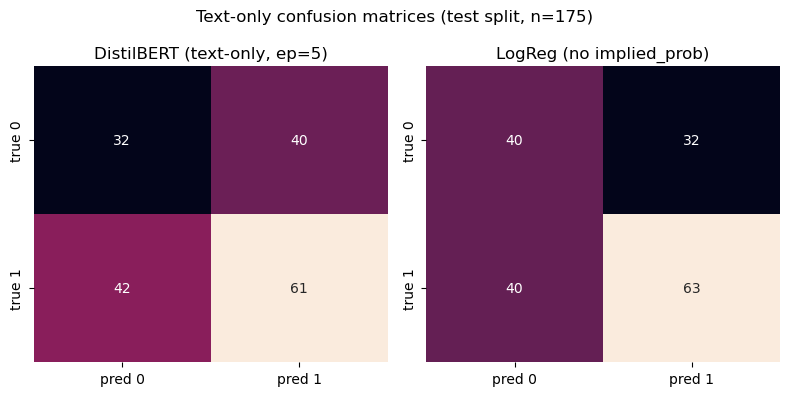

In [2]:
# DistilBERT confusion matrix + classification report
cm_bert = confusion_matrix(test_df['mentioned'], test_df['pred'], labels=[0, 1])
print('--- DistilBERT (text-only, lr=5e-5, ep=5) ---')
print(classification_report(test_df['mentioned'], test_df['pred'], labels=[0, 1],
                            target_names=['not_mentioned', 'mentioned'], zero_division=0))

# LogReg-no-implied_prob confusion matrix from experiments.jsonl.
# DistilBERT is text-only, so the fair classical comparator is the
# ablation where implied_prob is removed from the feature block.
# JSONL schema: config.{model,feature_set,split}, metrics.confusion_matrix.
exp_path = RESULTS_DIR / 'experiments.jsonl'
lr_cm = None
lr_metrics = None
with open(exp_path) as f:
    for line in f:
        rec = json.loads(line)
        cfg = rec.get('config', {})
        met = rec.get('metrics', {})
        if (cfg.get('model') == 'logreg'
                and cfg.get('feature_set') == 'no_implied_prob'
                and cfg.get('split') == 'test_ablation'
                and 'confusion_matrix' in met):
            lr_cm = np.asarray(met['confusion_matrix'])
            lr_metrics = met
assert lr_cm is not None, 'Could not find LogReg no_implied_prob test_ablation record in experiments.jsonl'
print('--- LogReg (no implied_prob, text+hist) — from experiments.jsonl ---')
print(f"test_f1_macro={lr_metrics['f1_macro']:.4f}  accuracy={lr_metrics['accuracy']:.4f}  "
      f"recall_pos={lr_metrics['recall_pos']:.4f}  recall_neg={lr_metrics['recall_neg']:.4f}")

# Side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, cm, title in [
    (axes[0], cm_bert, 'DistilBERT (text-only, ep=5)'),
    (axes[1], lr_cm,   'LogReg (no implied_prob)'),
]:
    sns.heatmap(cm, annot=True, fmt='d', cbar=False,
                xticklabels=['pred 0', 'pred 1'],
                yticklabels=['true 0', 'true 1'], ax=ax)
    ax.set_title(title)
fig.suptitle(f'Text-only confusion matrices (test split, n={len(test_df)})')
plt.tight_layout()
out = FIGURES_DIR / 'confusion_matrix_text_only.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'saved -> {out}')

## 2. Worst-N test errors

Highest-confidence wrong predictions. Compare model probability with Kalshi `implied_prob` — if both agree and both are wrong, the market genuinely mispriced the call (rare, given §4.3). If they disagree and DistilBERT is wrong, text-only signal was misleading.

n_errors=82 / 175 test rows (err_rate=0.469)


saved -> C:\Users\Kevin\Github\lin371\notebooks\..\outputs\results\figures\distilbert_probs_vs_implied.png


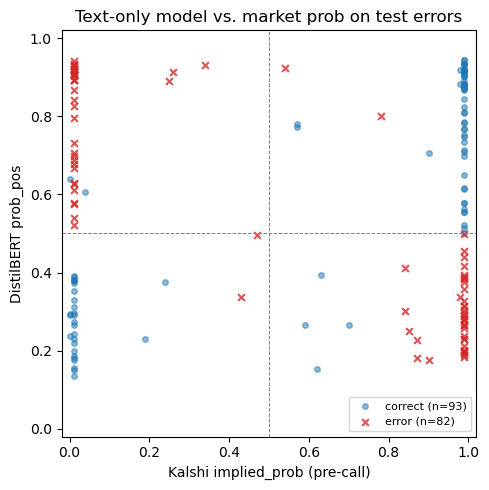

In [3]:
errors = test_df[test_df['pred'] != test_df['mentioned']].copy()
errors['confidence'] = np.where(errors['pred'] == 1, errors['prob_pos'], 1 - errors['prob_pos'])
errors = errors.sort_values('confidence', ascending=False)

print(f'n_errors={len(errors)} / {len(test_df)} test rows '
      f'(err_rate={len(errors)/len(test_df):.3f})')
display_cols = ['ticker', 'year', 'quarter', 'word', 'mentioned', 'pred',
                'prob_pos', 'implied_prob', 'hist_rate']
top = errors[display_cols].head(20)
top

# Scatter: for each test row, model prob_pos vs. Kalshi implied_prob,
# colored by correct/incorrect. If both concentrate near 0 or 1, the
# market and the text-only model agree on the easy cases — and errors
# are the cases where they diverge or where the market itself is wrong.
fig, ax = plt.subplots(figsize=(5, 5))
correct_mask = (test_df['pred'] == test_df['mentioned'])
ax.scatter(test_df.loc[correct_mask, 'implied_prob'],
           test_df.loc[correct_mask, 'prob_pos'],
           s=16, alpha=0.5, label=f'correct (n={int(correct_mask.sum())})',
           color='tab:blue')
ax.scatter(test_df.loc[~correct_mask, 'implied_prob'],
           test_df.loc[~correct_mask, 'prob_pos'],
           s=24, alpha=0.8, label=f'error (n={int((~correct_mask).sum())})',
           color='tab:red', marker='x')
ax.axhline(0.5, color='gray', lw=0.7, ls='--')
ax.axvline(0.5, color='gray', lw=0.7, ls='--')
ax.set_xlabel('Kalshi implied_prob (pre-call)')
ax.set_ylabel('DistilBERT prob_pos')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.legend(loc='lower right', fontsize=8)
ax.set_title('Text-only model vs. market prob on test errors')
plt.tight_layout()
out = FIGURES_DIR / 'distilbert_probs_vs_implied.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'saved -> {out}')

## 3. Seen-vs-unseen-word failure mode

Split errors by whether the target word ever appeared in the ticker's prior-quarter transcripts. Mayank's hypothesis: unseen words get systematically low predicted probability, which hurts No-buys when the word is about to be announced as a new product.

In [ ]:
import re

# Load prior-quarter transcripts once per ticker (expensive otherwise).
tickers = sorted(test_df['ticker'].unique())
prior_by_ticker = {t: load_transcripts(t) for t in tickers}

def seen_before(row) -> float:
    # Strictly-prior by real call date — same rule as build_labels hist_rate
    # (date sidecar in TRANSCRIPTS_DIR/_dates.csv). Avoids the (year, quarter)
    # leakage that hit fiscal-year-misaligned tickers; see FIX_LEAKAGE.md.
    row_date = pd.to_datetime(row.get('call_date'), errors='coerce')
    if pd.isna(row_date):
        return np.nan
    prior = []
    for doc in prior_by_ticker[row['ticker']]:
        d = pd.to_datetime(doc.get('date'), errors='coerce')
        if pd.notna(d) and d < row_date:
            prior.append(doc['content'])
    if not prior:
        return np.nan
    pat = re.compile(r'' + re.escape(str(row['word'])) + r'', re.IGNORECASE)
    return float(any(pat.search(d) for d in prior))
test_df['word_seen_before'] = test_df.apply(seen_before, axis=1)
test_df['correct'] = (test_df['pred'] == test_df['mentioned']).astype(int)

# (1) Summary by seen/unseen: base rate, model mean prob, accuracy
summary = test_df.groupby('word_seen_before', dropna=False).agg(
    n=('mentioned', 'size'),
    base_rate_mentioned=('mentioned', 'mean'),
    mean_prob_pos=('prob_pos', 'mean'),
    accuracy=('correct', 'mean'),
)
print('--- seen vs. unseen (base rate, mean model prob, accuracy) ---')
print(summary.round(4))

# (2) Mayank's sharper test: unseen-word × positive-label cell.
#     His hypothesis is that unseen words get systematically low prob,
#     so the model under-predicts the positive class when the word is
#     new. That predicts a much lower recall on (seen=0, mentioned=1)
#     than on (seen=1, mentioned=1).
print('\n--- error rate by (word_seen_before, mentioned) ---')
cross = test_df.groupby(['word_seen_before', 'mentioned'], dropna=False).agg(
    n=('mentioned', 'size'),
    err_rate=('correct', lambda s: 1 - float(s.mean())),
    mean_prob_pos=('prob_pos', 'mean'),
)
print(cross.round(4))

print('\n--- recall on mentioned=1, split by seen_before ---')
pos = test_df[test_df['mentioned'] == 1]
by_seen = pos.groupby('word_seen_before', dropna=False).agg(
    n=('mentioned', 'size'),
    recall=('pred', 'mean'),
    mean_prob_pos=('prob_pos', 'mean'),
)
print(by_seen.round(4))

No cleaned transcripts found for ticker: COINBASE


No cleaned transcripts found for ticker: DPZ


--- seen vs. unseen (base rate, mean model prob, accuracy) ---
                    n  base_rate_mentioned  mean_prob_pos  accuracy
word_seen_before                                                   
0.0               151               0.5762         0.5362    0.5099
NaN                24               0.6667         0.8968    0.6667

--- error rate by (word_seen_before, mentioned) ---
                             n  err_rate  mean_prob_pos
word_seen_before mentioned                             
0.0              0          64    0.5000         0.5315
                 1          87    0.4828         0.5397
NaN              0           8    1.0000         0.9110
                 1          16    0.0000         0.8897

--- recall on mentioned=1, split by seen_before ---
                   n  recall  mean_prob_pos
word_seen_before                           
0.0               87  0.5172         0.5397
NaN               16  1.0000         0.8897


## 4. Per-ticker breakdown

Which of the 15 test tickers carries most of the errors? If errors concentrate on one or two tickers, the cross-company split is exposing a specific distribution-shift failure.

           n  accuracy  n_errors  mean_prob_pos  base_rate_mentioned
ticker                                                              
HIMS      14    0.3571         9         0.4652               0.6429
CELH      13    0.3846         8         0.5618               0.3077
UBER      16    0.5000         8         0.6172               0.6250
MTN       12    0.4167         7         0.5705               0.5000
TSLA      17    0.5882         7         0.6047               0.7059
CAR       10    0.4000         6         0.6145               0.6000
DPZ       10    0.4000         6         0.8836               0.4000
WGO        9    0.3333         6         0.5762               0.5556
ADBE      11    0.5455         5         0.3259               0.4545
AIR        9    0.4444         5         0.4815               0.3333
RKLB      13    0.6154         5         0.4061               0.6923
GEV        9    0.5556         4         0.5466               0.8889
CCL       10    0.7000         3  

saved -> C:\Users\Kevin\Github\lin371\notebooks\..\outputs\results\figures\distilbert_errors_by_ticker.png


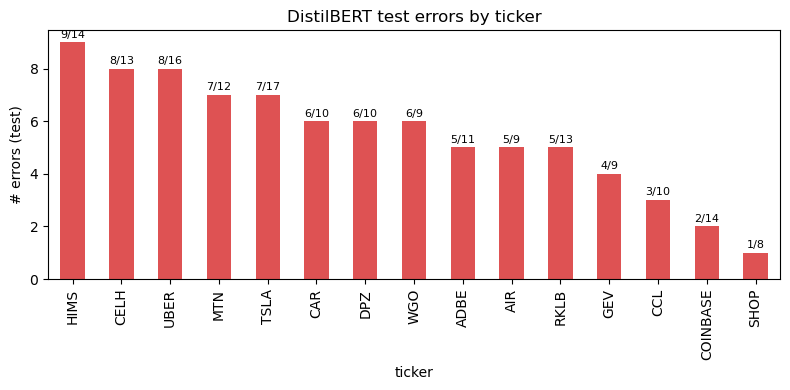

In [5]:
per_ticker = test_df.groupby('ticker').agg(
    n=('mentioned', 'size'),
    accuracy=('correct', 'mean'),
    n_errors=('correct', lambda s: int((1 - s).sum())),
    mean_prob_pos=('prob_pos', 'mean'),
    base_rate_mentioned=('mentioned', 'mean'),
).sort_values('n_errors', ascending=False)
print(per_ticker.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
per_ticker['n_errors'].plot(kind='bar', ax=ax, color='tab:red', alpha=0.8)
ax.set_ylabel('# errors (test)')
ax.set_xlabel('ticker')
ax.set_title('DistilBERT test errors by ticker')
for i, (n, e) in enumerate(zip(per_ticker['n'], per_ticker['n_errors'])):
    ax.text(i, e + 0.1, f'{e}/{n}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
out = FIGURES_DIR / 'distilbert_errors_by_ticker.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'saved -> {out}')